In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score


In [ ]:
# Load train and test datasets

train_df = pd.read_csv(
    r"C:\hireai-ml\data\processed\train.csv"
)

test_df = pd.read_csv(
    r"C:\hireai-ml\data\processed\test.csv"
)

# Train data preview
print(train_df.shape)

print(train_df.columns)

print(train_df.head())

# Test data preview
print(test_df.shape)

print(test_df.columns)

print(test_df.head())

(79840, 22)
Index(['application_id', 'candidate_id', 'job_id', 'application_date',
       'status', 'name', 'email', 'skills', 'experience_years', 'education',
       'projects', 'role', 'required_skills', 'min_experience', 'score',
       'skills_match', 'experience_score', 'project_score', 'label',
       'num_candidate_skills', 'num_required_skills', 'experience_difference'],
      dtype='object')
   application_id  candidate_id  job_id application_date       status  \
0           66735         30433       7       2026-03-11      applied   
1           64779         29450      10       2025-08-03  interviewed   
2           17695          5854       8       2025-09-27  shortlisted   
3           45409         19740       7       2025-08-16  shortlisted   
4           40653         17363       7       2025-09-12      applied   

               name                              email  \
0          pooja li              pooja.li5775@zoho.com   
1      meera pillai           meera.pilla

In [ ]:
target = 'label'

# Train features and target
X_train = train_df.drop(
    columns=['candidate_id', 'job_id', target]
)

y_train = train_df[target]

# Test features and target
X_test = test_df.drop(
    columns=['candidate_id', 'job_id', target]
)

y_test = test_df[target]

# Shapes
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

In [ ]:
print(X_train.dtypes)

application_id             int64
application_date          object
status                    object
name                      object
email                     object
skills                    object
experience_years           int64
education                 object
projects                  object
role                      object
required_skills           object
min_experience             int64
score                    float64
skills_match             float64
experience_score         float64
project_score            float64
num_candidate_skills       int64
num_required_skills        int64
experience_difference      int64
dtype: object


In [ ]:
# Convert object columns to string

for col in X_train.columns:

    if X_train[col].dtype == 'object':

        X_train[col] = X_train[col].astype(str)

        X_test[col] = X_test[col].astype(str)

# Detect categorical columns
cat_features = X_train.select_dtypes(
    include=['object']
).columns

print(cat_features)

# Convert categorical column names to indices
cat_feature_indices = [
    X_train.columns.get_loc(col)
    for col in cat_features
]

print(cat_feature_indices)

Index(['application_date', 'status', 'name', 'email', 'skills', 'education',
       'projects', 'role', 'required_skills'],
      dtype='object')
[1, 2, 3, 4, 5, 7, 8, 9, 10]


In [9]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.03,
    depth=6,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=50
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_feature_indices
)

y_pred = model.predict(X_test)

print(y_pred[:5])

0:	learn: 0.6298221	total: 487ms	remaining: 48.2s
50:	learn: 0.6298065	total: 12.2s	remaining: 11.7s
99:	learn: 0.6298065	total: 20.9s	remaining: 0us
[['average fit']
 ['average fit']
 ['average fit']
 ['average fit']
 ['average fit']]


In [ ]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	learn: 0.6298221	test: 0.6333918	best: 0.6333918 (0)	total: 203ms	remaining: 20.1s
50:	learn: 0.6298065	test: 0.6333918	best: 0.6333918 (0)	total: 8.3s	remaining: 7.98s
99:	learn: 0.6298065	test: 0.6333918	best: 0.6333918 (0)	total: 16.1s	remaining: 0us

bestTest = 0.6333917836
bestIteration = 0

Shrink model to first 1 iterations.


CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=100, learning_rate=0.03, loss_function='MultiClass', random_seed=42, verbose=50)

In [13]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[['average fit']
 ['average fit']
 ['average fit']
 ['average fit']
 ['average fit']]


In [14]:
import numpy as np

y_pred = np.array(y_pred).flatten()

print(y_pred[:5])

['average fit' 'average fit' 'average fit' 'average fit' 'average fit']


In [ ]:
from src.eval.metrics import classification_metrics

results = classification_metrics(
    y_test,
    y_pred
)

print(results)

{'accuracy': 0.6333917835671342, 'precision': 0.6514462879239509, 'recall': 0.6333917835671342, 'f1': 0.6053293245482002, 'confusion_matrix': array([[6750,  232, 1157],
       [2258,  510,    0],
       [2207,    0, 2854]])}


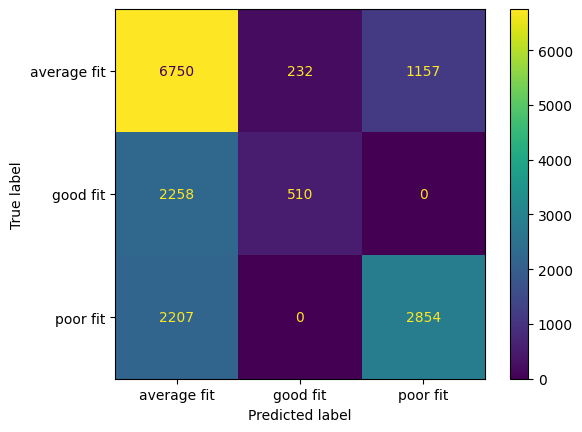

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [ ]:
import pandas as pd

error_df = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

print(error_df.head())

            actual    predicted
72244  average fit  average fit
18924  average fit  average fit
41104  average fit  average fit
63011     good fit  average fit
19371  average fit  average fit


In [ ]:
import sys
import os

sys.path.append(r"C:\hireai-ml")
from src.eval.error_analysis import classification_error_analysis

errors = classification_error_analysis(
    y_test,
    y_pred
)

print(errors)

            actual    predicted
63011     good fit  average fit
79729     poor fit  average fit
61189     good fit  average fit
60601     good fit  average fit
19547     good fit  average fit
...            ...          ...
39935     poor fit  average fit
59801     poor fit  average fit
31539     poor fit  average fit
64451  average fit     good fit
78935     good fit  average fit

[5854 rows x 2 columns]


In [ ]:
feature_importance = model.get_feature_importance()

importance_df = pd.DataFrame({
    "Feature": list(X_train.columns),
    "Importance": list(feature_importance)
})

print(importance_df)

                  Feature  Importance
0          application_id    0.000000
1        application_date    0.000000
2                  status    0.000000
3                    name    0.000000
4                   email    0.000000
5                  skills    0.000000
6        experience_years    0.000000
7               education    0.000000
8                projects    0.000000
9                    role    0.076612
10        required_skills    0.010104
11         min_experience    0.000000
12                  score   99.850398
13           skills_match    0.062886
14       experience_score    0.000000
15          project_score    0.000000
16   num_candidate_skills    0.000000
17    num_required_skills    0.000000
18  experience_difference    0.000000


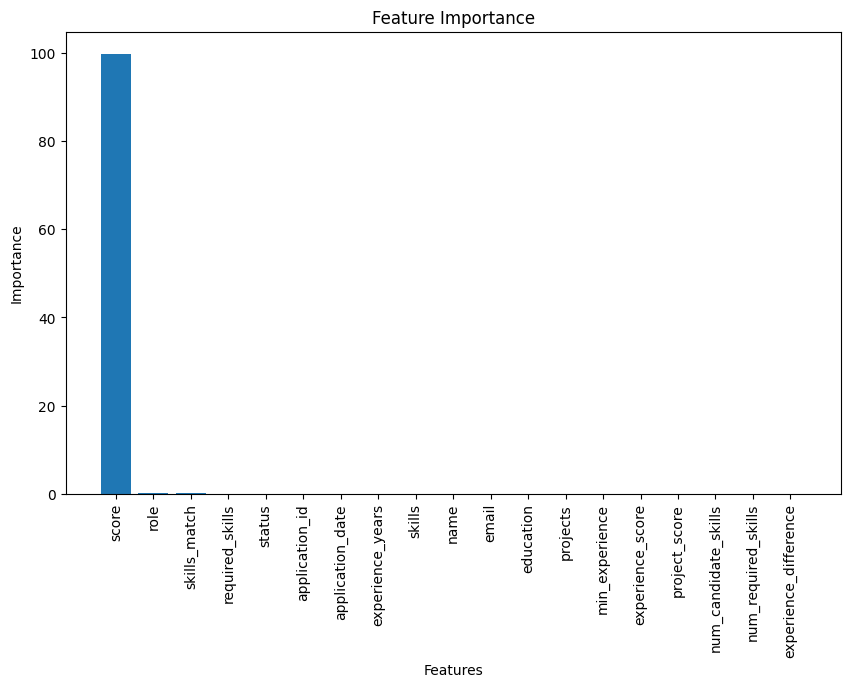

In [ ]:
import matplotlib.pyplot as plt

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=90)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance")

plt.show()

# M3 Week 2 Findings

- CatBoost multiclass model evaluated successfully
- Classification metrics computed
- Confusion matrix generated
- Error analysis completed
- Feature importance extracted for explainability